# Install Dependencies

In [1]:
!pip install -r dependencies.txt

In [2]:
import numpy as np
import gym
import pickle
import matplotlib.pyplot as plt
import pygame
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

from gym import logger as gymlogger
from gym.wrappers import RecordVideo
gymlogger.set_level(40) #error only
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data=''''''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

# Initialize CartPole Environment

In [3]:
# observation space

env = gym.make('CartPole-v1')
print("CartPole Environment:")
print("Shape of observation space: ", env.observation_space.shape[0])
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

CartPole Environment:
Shape of observation space:  4
Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


# Task 1: Development of an RL Agent

Demonstrate the correctness of the implementation by sampling a random state from the cart pole environment, inputting to the agent, and outputting a chosen action. Print the values of the state and chosen action in Jupyter notebook.



## 1.1 DEEP Q-Learning (DQL) Agent for CartPole

- Uses a neural network instead of a Q-table.
- Implements experience replay to improve stability.
- Uses a target network to stabilize learning.
- Uses epsilon-greedy policy for exploration.

### DQL Implementation

In [4]:
# Neural Network for Q-value approximation
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)  # Increased from 64 to 128
        self.fc2 = nn.Linear(128, 128)         # Increased from 64 to 128
        self.fc3 = nn.Linear(128, action_size)
        
        # Initialize weights for better training
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DQLAgent:
    def __init__(self, env, gamma=0.99, lr=0.0005, batch_size=128, memory_size=20000,
                 epsilon=1.0, epsilon_decay=0.99, epsilon_min=0.01, target_update_freq=5):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_decay = epsilon_decay  # Decay rate for epsilon
        self.epsilon_min = epsilon_min  # Minimum exploration rate
        self.batch_size = batch_size  # Batch size for training
        self.target_update_freq = target_update_freq  # Target network update frequency
        self.lr = lr  # Store learning rate

        # Memory for experience replay
        self.memory = deque(maxlen=memory_size)

        # Q-network (main network)
        self.q_network = DQN(self.state_size, self.action_size)
        self.target_network = DQN(self.state_size, self.action_size)
        self.target_network.load_state_dict(self.q_network.state_dict())  # Copy weights
        self.target_network.eval()  # Target network does not update with gradients

        # Optimizer with custom learning rate
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

    def set_learning_rate(self, new_lr):
        """ Update the learning rate of the optimizer dynamically. """
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = new_lr

    def select_action(self, state, training=True):
        """ Select action using epsilon-greedy policy """
        if training and np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Random action
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        """ Store experience in replay memory with uniform shapes """
        self.memory.append((
            np.array(state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            action,
            reward,
            np.array(next_state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            done
        ))

    def train_step(self):
        """ Train the agent using a batch of experiences """
        if len(self.memory) < self.batch_size:
            return

        # Sample mini-batch from memory
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert states and next_states to uniform NumPy arrays before stacking
        states = torch.FloatTensor(np.array(states, dtype=np.float32).reshape(self.batch_size, -1))
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states, dtype=np.float32).reshape(self.batch_size, -1))
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1)

        # Compute Q-values
        q_values = self.q_network(states).gather(1, actions)

        # Compute target Q-values
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = F.mse_loss(q_values, target_q_values)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self, num_episodes=1000):
        """ Train the agent using Deep Q-Learning with improvements """
        rewards_per_episode = []
        recent_rewards = deque(maxlen=10)  # Changed from 100 to 10
        last_10_rewards = deque(maxlen=10)  # For early stopping based on last 10 episodes
        
        for episode in range(num_episodes):
            reset_output = self.env.reset()
            
            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions
                
            state = np.array(state, dtype=np.float32).reshape(-1)  # Flatten state
            total_reward = 0
            done = False
            
            while not done:
                action = self.select_action(state)
                
                # Handle both Gym and Gymnasium versions
                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags
                    
                next_state = np.array(next_state, dtype=np.float32).reshape(-1)
                self.store_experience(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
                
                self.train_step()
                
            rewards_per_episode.append(total_reward)
            recent_rewards.append(total_reward)
            last_10_rewards.append(total_reward)  # Add to last 10 tracking
            
            # Update target network
            if episode % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())
                
            # Decay epsilon
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
            
            # Learning rate scheduler
            if episode > 0 and episode % 100 == 0:
                avg_recent = sum(recent_rewards) / len(recent_rewards) if recent_rewards else 0
                if avg_recent < 150:  # If performance is lagging
                    new_lr = self.lr * 0.5
                    self.set_learning_rate(new_lr)
                    self.lr = new_lr
                    print(f"Reducing learning rate to {new_lr}")
            
            # Print progress every 10 episodes
            if episode % 10 == 0:
                avg_reward = sum(recent_rewards) / len(recent_rewards) if recent_rewards else 0
                
                # Calculate last 10 average
                last_10_avg = sum(last_10_rewards) / len(last_10_rewards) if last_10_rewards else 0
                
                print(f"Episode {episode}/{num_episodes}, Total Reward: {total_reward}, Avg(last {len(recent_rewards)}): {avg_reward:.2f}, Epsilon: {self.epsilon:.3f}")
                
                # Early stopping if last 10 episodes have average reward above 220
                # Check if all of the last 10 episodes have reward > 195 AND the average is > 220
                if len(last_10_rewards) == 10 and last_10_avg > 220 and all(reward > 195 for reward in last_10_rewards):
                    print(f"Early stopping at episode {episode} with last 10 episodes average reward {last_10_avg:.2f}")
                    print(f"All of the last 10 episodes exceeded the 195 threshold")
                    break
                    
        self.plot_rewards(rewards_per_episode)
        return rewards_per_episode  # Return for evaluation

    def test(self, num_episodes=10):
        """ Test the agent without training """
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state, training=False)

                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure next state is (4,)
                total_reward += reward

            print(f"Episode {episode+1}, Total Reward: {total_reward}")

    def plot_rewards(self, rewards):
        """ Plot the rewards over episodes """
        plt.figure(figsize=(10, 6))
        plt.plot(rewards)
        plt.xlabel('Episodes')
        plt.ylabel('Rewards')
        plt.title('Training Rewards over Episodes')
        plt.grid(True)
        plt.show()

    def save_model(self, filename='dql_cartpole.pth'):
        """ Save trained model """
        torch.save(self.q_network.state_dict(), filename)

    def load_model(self, filename='dql_cartpole.pth'):
        """ Load trained model """
        self.q_network.load_state_dict(torch.load(filename))
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.q_network.eval()
        self.target_network.eval()

# Task 1: Demonstrate agent action on a random state
def demonstrate_agent_action(agent, env):
    print("\n--- Task 1: Demonstrating Agent Action Selection ---")
    # Reset the environment to get a random state
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    
    # Print the state values
    print("Random state from environment:")
    print(f"  Cart Position: {state[0]:.6f}")
    print(f"  Cart Velocity: {state[1]:.6f}")
    print(f"  Pole Angle: {state[2]:.6f}")
    print(f"  Pole Angular Velocity: {state[3]:.6f}")
    
    # Get and print action
    action = agent.select_action(state, training=False)
    action_name = "Left" if action == 0 else "Right"
    print(f"Agent's chosen action: {action} ({action_name})")
    
    return state, action

# Task 2: Evaluate agent over 100 episodes
def evaluate_agent(agent, env, num_episodes=100):
    """
    Enhanced evaluation function that builds on your existing evaluate_agent
    with additional useful metrics.
    """
    print("\n=== Enhanced Agent Evaluation ===")
    rewards = []
    episode_lengths = []
    actions_distribution = [0, 0]  # Count of [left, right] actions
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        
        state = np.array(state, dtype=np.float32).reshape(-1)
        total_reward = 0
        done = False
        steps = 0
        
        while not done:
            action = agent.select_action(state, training=False)
            actions_distribution[action] += 1
            
            step_result = env.step(action)
            if len(step_result) == 4:
                next_state, reward, done, info = step_result
            else:
                next_state, reward, done, truncated, info = step_result
                done = done or truncated
                
            state = np.array(next_state, dtype=np.float32).reshape(-1)
            total_reward += reward
            steps += 1
            
        rewards.append(total_reward)
        episode_lengths.append(steps)
        
        if (episode + 1) % 20 == 0:
            print(f"Evaluation episode {episode + 1}/{num_episodes}, Reward: {total_reward}")
    
    # Calculate metrics
    avg_reward = np.mean(rewards)
    median_reward = np.median(rewards)
    success_rate = sum(1 for r in rewards if r >= 195) / num_episodes
    avg_episode_length = np.mean(episode_lengths)
    reward_std = np.std(rewards)
    
    # Print metrics
    print("\n=== Evaluation Results ===")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Median Reward: {median_reward:.2f}")
    print(f"Reward Standard Deviation: {reward_std:.2f}")
    print(f"Success Rate (reward ≥ 195): {success_rate:.2%}")
    print(f"Average Episode Length: {avg_episode_length:.2f} steps")
    
    # Action distribution
    total_actions = sum(actions_distribution)
    print(f"Action Distribution: Left: {actions_distribution[0]/total_actions:.2%}, Right: {actions_distribution[1]/total_actions:.2%}")
    
    # Create visualizations
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Reward distribution histogram
    axs[0].hist(rewards, bins=20, alpha=0.7)
    axs[0].axvline(x=195, color='r', linestyle='--', label='Target (195)')
    axs[0].axvline(x=avg_reward, color='g', linestyle='-', label=f'Average ({avg_reward:.2f})')
    axs[0].set_title('Reward Distribution')
    axs[0].set_xlabel('Reward')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()
    
    # 2. Episode rewards
    axs[1].plot(rewards, marker='o', linestyle='-', alpha=0.5)
    axs[1].axhline(y=195, color='r', linestyle='--', label='Target (195)')
    axs[1].axhline(y=avg_reward, color='g', linestyle='-', label=f'Average ({avg_reward:.2f})')
    axs[1].set_title('Episode Rewards')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Reward')
    axs[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print final assessment
    print("\n=== Overall Assessment ===")
    if avg_reward > 195 and success_rate > 0.9:
        print("✅ EXCELLENT: Your agent consistently solves the environment!")
    elif avg_reward > 150 and success_rate > 0.7:
        print("✓ GOOD: Your agent performs well but could be improved for more consistency.")
    elif avg_reward > 100:
        print("⚠ FAIR: Your agent shows some learning but fails too often.")
    else:
        print("❌ POOR: Your agent needs significant improvement.")
    
    return rewards, avg_reward, success_rate, median_reward, reward_std

agent = DQLAgent(env)

### Create & Train Agent (DO NOT RUN)

C:\Users\User\anaconda3\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 0/500, Total Reward: 24.0, Avg(last 1): 24.00, Epsilon: 0.990
Episode 10/500, Total Reward: 54.0, Avg(last 10): 29.20, Epsilon: 0.895
Episode 20/500, Total Reward: 23.0, Avg(last 10): 28.50, Epsilon: 0.810
Episode 30/500, Total Reward: 19.0, Avg(last 10): 28.20, Epsilon: 0.732
Episode 40/500, Total Reward: 64.0, Avg(last 10): 30.20, Epsilon: 0.662
Episode 50/500, Total Reward: 34.0, Avg(last 10): 63.70, Epsilon: 0.599
Episode 60/500, Total Reward: 192.0, Avg(last 10): 84.00, Epsilon: 0.542
Episode 70/500, Total Reward: 67.0, Avg(last 10): 89.50, Epsilon: 0.490
Episode 80/500, Total Reward: 189.0, Avg(last 10): 120.40, Epsilon: 0.443
Episode 90/500, Total Reward: 173.0, Avg(last 10): 118.30, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 144.0, Avg(last 10): 125.60, Epsilon: 0.362
Episode 110/500, Total Reward: 15.0, Avg(last 10): 116.70, Epsilon: 0.328
Episode 120/500, Total Reward: 133.0, Avg(last 10): 154.90, Epsilon: 0.296
Episode 130/500, To

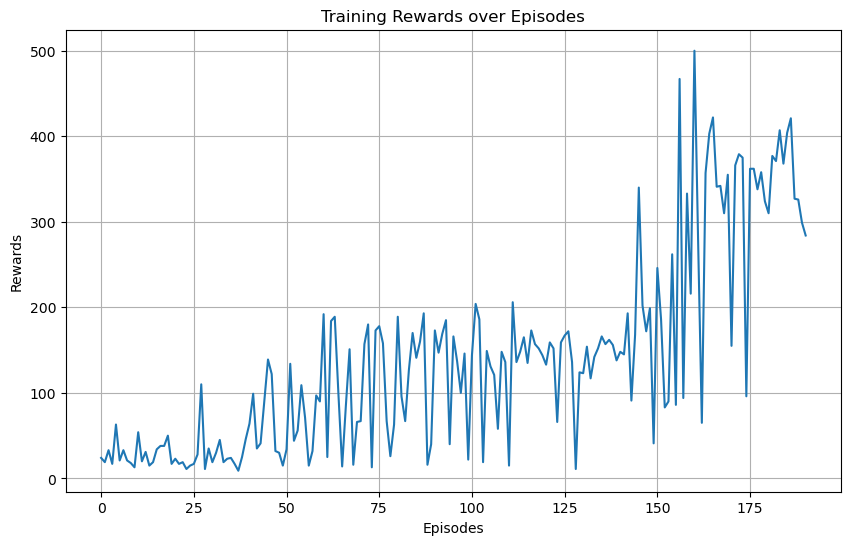

[24.0,
 19.0,
 33.0,
 17.0,
 63.0,
 21.0,
 33.0,
 21.0,
 18.0,
 13.0,
 54.0,
 20.0,
 31.0,
 15.0,
 19.0,
 34.0,
 38.0,
 38.0,
 50.0,
 17.0,
 23.0,
 17.0,
 19.0,
 11.0,
 15.0,
 17.0,
 28.0,
 110.0,
 11.0,
 35.0,
 19.0,
 30.0,
 45.0,
 19.0,
 23.0,
 24.0,
 17.0,
 9.0,
 25.0,
 46.0,
 64.0,
 99.0,
 35.0,
 41.0,
 90.0,
 139.0,
 122.0,
 32.0,
 30.0,
 15.0,
 34.0,
 134.0,
 44.0,
 56.0,
 109.0,
 71.0,
 15.0,
 32.0,
 97.0,
 90.0,
 192.0,
 25.0,
 184.0,
 189.0,
 98.0,
 14.0,
 85.0,
 151.0,
 16.0,
 66.0,
 67.0,
 157.0,
 180.0,
 13.0,
 173.0,
 178.0,
 158.0,
 67.0,
 26.0,
 63.0,
 189.0,
 96.0,
 67.0,
 127.0,
 170.0,
 141.0,
 160.0,
 193.0,
 16.0,
 40.0,
 173.0,
 147.0,
 169.0,
 185.0,
 40.0,
 166.0,
 137.0,
 100.0,
 146.0,
 22.0,
 144.0,
 204.0,
 186.0,
 19.0,
 149.0,
 131.0,
 121.0,
 58.0,
 148.0,
 136.0,
 15.0,
 206.0,
 136.0,
 148.0,
 165.0,
 135.0,
 173.0,
 157.0,
 152.0,
 144.0,
 133.0,
 159.0,
 152.0,
 66.0,
 159.0,
 167.0,
 172.0,
 136.0,
 11.0,
 124.0,
 123.0,
 154.0,
 117.0,
 142.0,
 152.0

In [5]:
agent.train(num_episodes=500)  # Train the agent

### Save Trained Model (DO NOT RUN)

In [6]:
agent.save_model('dql_cartpole.pth')
print("Model saved to dql_cartpole.pth")

Model saved to dql_cartpole.pth


### Test Trained Agent and Evaluation

Episode 1, Total Reward: 377.0
Episode 2, Total Reward: 358.0
Episode 3, Total Reward: 378.0
Episode 4, Total Reward: 365.0
Episode 5, Total Reward: 136.0
Episode 6, Total Reward: 143.0
Episode 7, Total Reward: 142.0
Episode 8, Total Reward: 381.0
Episode 9, Total Reward: 381.0
Episode 10, Total Reward: 367.0

=== Enhanced Agent Evaluation ===
Evaluation episode 20/100, Reward: 360.0
Evaluation episode 40/100, Reward: 405.0
Evaluation episode 60/100, Reward: 166.0
Evaluation episode 80/100, Reward: 367.0
Evaluation episode 100/100, Reward: 356.0

=== Evaluation Results ===
Average Reward: 329.53
Median Reward: 369.50
Reward Standard Deviation: 96.67
Success Rate (reward ≥ 195): 81.00%
Average Episode Length: 329.53 steps
Action Distribution: Left: 49.92%, Right: 50.08%


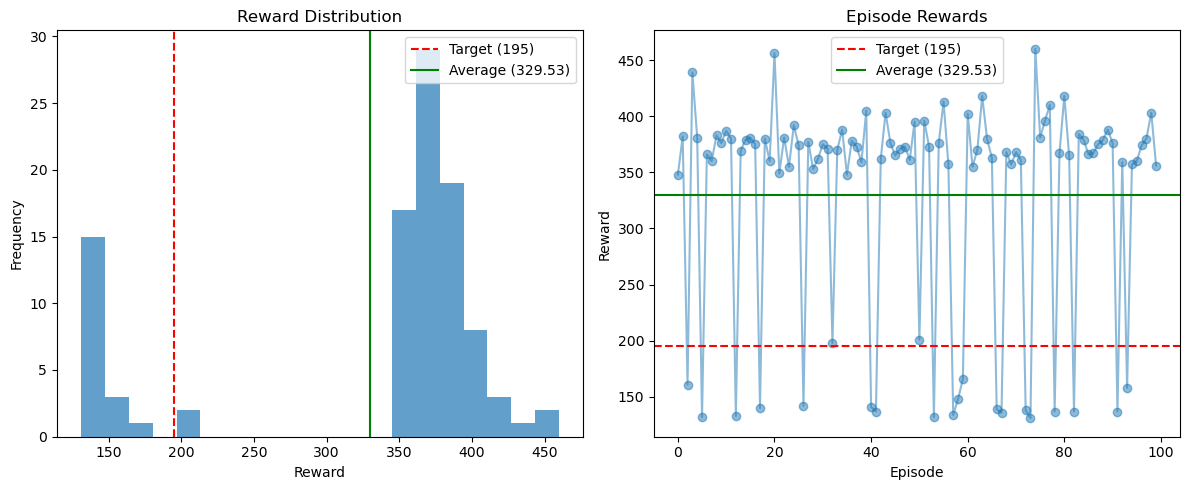


=== Overall Assessment ===
✓ GOOD: Your agent performs well but could be improved for more consistency.


In [7]:
agent.load_model('dql_cartpole.pth')
agent.test(num_episodes=10)
rewards, avg_reward, success_rate, median_reward, reward_std = evaluate_agent(agent, env, num_episodes=100)

### Render one episode

In [8]:
import gym
import numpy as np
import os

# Create video directory
if not os.path.exists("./video"):
    os.makedirs("./video")

# Enable video recording for the initial evaluation
record_video = True    
    
# Create environment with video recording capability
env = gym.wrappers.RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./video",
    episode_trigger=lambda episode_id: record_video  # Recording on/off
)


# Reset the environment
observation = env.reset()

# Handle different types of observation structures
if isinstance(observation, tuple):
    observation = observation[0]

# Ensure observation is properly formatted
observation = np.array(observation, dtype=np.float32)

# Run one episode with trained agent
done = False
cumulative_reward = 0
steps = 0

while not done:
    # Use trained agent to select actions
    action = agent.select_action(observation, training=False)
    
    # Take a step in the environment
    step_result = env.step(action)
    
    # Handle different possible step return formats
    if len(step_result) == 4:
        observation, reward, done, info = step_result
    else:
        observation, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    
    # Ensure observation is properly formatted
    observation = np.array(observation, dtype=np.float32)
    
    cumulative_reward += reward
    steps += 1
    
    # Optional: print step details
    print(f"Step {steps}, Action: {action}, Reward: {reward}, Done: {done}")

# Close the environment
env.close()

print(f"Episode finished after {steps} steps")
print(f"Cumulative reward: {cumulative_reward}")
print(f"Video should be saved to: {os.path.abspath('./video')}")

# List all files in the video directory
try:
    video_files = os.listdir("./video")
    print(f"Files in video directory: {video_files}")
except Exception as e:
    print(f"Error listing video directory: {e}")

Step 1, Action: 0, Reward: 1.0, Done: False
Step 2, Action: 0, Reward: 1.0, Done: False
Step 3, Action: 1, Reward: 1.0, Done: False
Step 4, Action: 0, Reward: 1.0, Done: False
Step 5, Action: 1, Reward: 1.0, Done: False
Step 6, Action: 0, Reward: 1.0, Done: False
Step 7, Action: 1, Reward: 1.0, Done: False
Step 8, Action: 1, Reward: 1.0, Done: False
Step 9, Action: 1, Reward: 1.0, Done: False
Step 10, Action: 1, Reward: 1.0, Done: False
Step 11, Action: 1, Reward: 1.0, Done: False
Step 12, Action: 1, Reward: 1.0, Done: False
Step 13, Action: 1, Reward: 1.0, Done: False
Step 14, Action: 0, Reward: 1.0, Done: False
Step 15, Action: 0, Reward: 1.0, Done: False
Step 16, Action: 1, Reward: 1.0, Done: False
Step 17, Action: 0, Reward: 1.0, Done: False
Step 18, Action: 0, Reward: 1.0, Done: False
Step 19, Action: 0, Reward: 1.0, Done: False
Step 20, Action: 0, Reward: 1.0, Done: False
Step 21, Action: 0, Reward: 1.0, Done: False
Step 22, Action: 0, Reward: 1.0, Done: False
Step 23, Action: 0,

Step 229, Action: 0, Reward: 1.0, Done: False
Step 230, Action: 1, Reward: 1.0, Done: False
Step 231, Action: 1, Reward: 1.0, Done: False
Step 232, Action: 0, Reward: 1.0, Done: False
Step 233, Action: 0, Reward: 1.0, Done: False
Step 234, Action: 1, Reward: 1.0, Done: False
Step 235, Action: 1, Reward: 1.0, Done: False
Step 236, Action: 0, Reward: 1.0, Done: False
Step 237, Action: 0, Reward: 1.0, Done: False
Step 238, Action: 1, Reward: 1.0, Done: False
Step 239, Action: 1, Reward: 1.0, Done: False
Step 240, Action: 0, Reward: 1.0, Done: False
Step 241, Action: 1, Reward: 1.0, Done: False
Step 242, Action: 0, Reward: 1.0, Done: False
Step 243, Action: 0, Reward: 1.0, Done: False
Step 244, Action: 1, Reward: 1.0, Done: False
Step 245, Action: 1, Reward: 1.0, Done: False
Step 246, Action: 0, Reward: 1.0, Done: False
Step 247, Action: 0, Reward: 1.0, Done: False
Step 248, Action: 1, Reward: 1.0, Done: False
Step 249, Action: 1, Reward: 1.0, Done: False
Step 250, Action: 0, Reward: 1.0, 

MoviePy - Done !
MoviePy - video ready C:\Users\User\Desktop\SCHOOL\Y2S2\SC3000 AI\SC3000_AI-main (ZL Verison, running it on my computer)\cartpole_RL\video\rl-video-episode-0.mp4
Step 368, Action: 0, Reward: 1.0, Done: True
Episode finished after 368 steps
Cumulative reward: 368.0
Video should be saved to: C:\Users\User\Desktop\SCHOOL\Y2S2\SC3000 AI\SC3000_AI-main (ZL Verison, running it on my computer)\cartpole_RL\video
Files in video directory: ['rl-video-episode-0.meta.json', 'rl-video-episode-0.mp4']


## 1.2 Fine-Tuning

### Learning Rate Scheduling

In the base DQL agent, the learning rate (lr) is fixed at 0.0005. However, dynamic learning rates often improve convergence. 

Here, we introduce two alternatives:
- Cosine Annealing: The learning rate gradually decreases in a wave-like pattern, helping the model avoid local minima.

- Exponential Decay: The learning rate decreases by a fixed factor (γ=0.99) every 100 episodes.

In [9]:
# Disable video recording
record_video = False

In [10]:
import torch.optim.lr_scheduler as lr_scheduler

class DQLAgentFineTuned(DQLAgent):
    def __init__(self, env, lr_schedule='fixed', **kwargs):
        super().__init__(env, **kwargs)
        self.lr_schedule = lr_schedule
        
        if self.lr_schedule == 'cosine':
            self.scheduler = lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=500)
        elif self.lr_schedule == 'exponential':
            self.scheduler = lr_scheduler.ExponentialLR(self.optimizer, gamma=0.99)

    def train_step(self):
        super().train_step()
        if self.lr_schedule in ['cosine', 'exponential']:
            self.scheduler.step()


In [13]:
def run_experiment(agent_class, env, params, num_episodes=500):
    agent = agent_class(env, **params)
    rewards = agent.train(num_episodes)
    return rewards

### Run and compare performance

Episode 0/500, Total Reward: 16.0, Avg(last 1): 16.00, Epsilon: 0.990
Episode 10/500, Total Reward: 15.0, Avg(last 10): 16.90, Epsilon: 0.895
Episode 20/500, Total Reward: 46.0, Avg(last 10): 25.70, Epsilon: 0.810
Episode 30/500, Total Reward: 12.0, Avg(last 10): 27.50, Epsilon: 0.732
Episode 40/500, Total Reward: 91.0, Avg(last 10): 37.20, Epsilon: 0.662
Episode 50/500, Total Reward: 44.0, Avg(last 10): 48.20, Epsilon: 0.599
Episode 60/500, Total Reward: 29.0, Avg(last 10): 49.50, Epsilon: 0.542
Episode 70/500, Total Reward: 51.0, Avg(last 10): 94.30, Epsilon: 0.490
Episode 80/500, Total Reward: 243.0, Avg(last 10): 147.30, Epsilon: 0.443
Episode 90/500, Total Reward: 255.0, Avg(last 10): 121.80, Epsilon: 0.401
Episode 100/500, Total Reward: 223.0, Avg(last 10): 171.50, Epsilon: 0.362
Episode 110/500, Total Reward: 154.0, Avg(last 10): 153.20, Epsilon: 0.328
Episode 120/500, Total Reward: 190.0, Avg(last 10): 167.60, Epsilon: 0.296
Episode 130/500, Total Reward: 135.0, Avg(last 10): 1

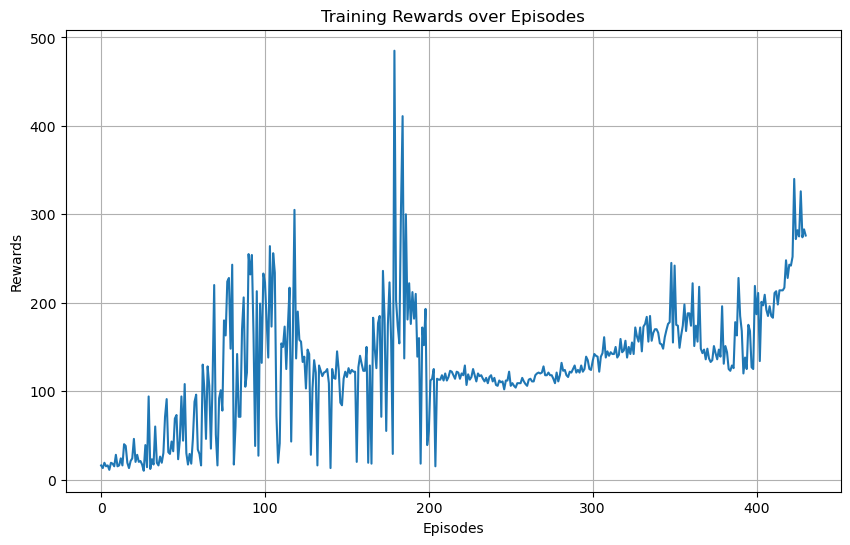

Episode 0/500, Total Reward: 47.0, Avg(last 1): 47.00, Epsilon: 0.990


C:\Users\User\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Episode 10/500, Total Reward: 31.0, Avg(last 10): 15.80, Epsilon: 0.895
Episode 20/500, Total Reward: 33.0, Avg(last 10): 18.70, Epsilon: 0.810
Episode 30/500, Total Reward: 16.0, Avg(last 10): 17.40, Epsilon: 0.732
Episode 40/500, Total Reward: 10.0, Avg(last 10): 14.00, Epsilon: 0.662
Episode 50/500, Total Reward: 52.0, Avg(last 10): 27.60, Epsilon: 0.599
Episode 60/500, Total Reward: 27.0, Avg(last 10): 49.10, Epsilon: 0.542
Episode 70/500, Total Reward: 141.0, Avg(last 10): 123.10, Epsilon: 0.490
Episode 80/500, Total Reward: 185.0, Avg(last 10): 83.70, Epsilon: 0.443
Episode 90/500, Total Reward: 207.0, Avg(last 10): 126.10, Epsilon: 0.401
Episode 100/500, Total Reward: 223.0, Avg(last 10): 177.70, Epsilon: 0.362
Episode 110/500, Total Reward: 200.0, Avg(last 10): 197.60, Epsilon: 0.328
Episode 120/500, Total Reward: 146.0, Avg(last 10): 204.10, Epsilon: 0.296
Episode 130/500, Total Reward: 314.0, Avg(last 10): 212.10, Epsilon: 0.268
Episode 140/500, Total Reward: 237.0, Avg(last 

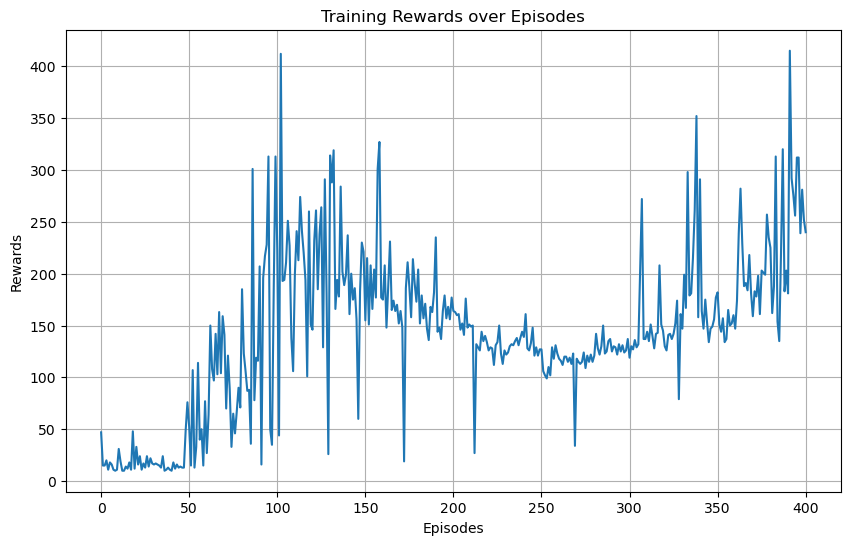

Episode 0/500, Total Reward: 18.0, Avg(last 1): 18.00, Epsilon: 0.990
Episode 10/500, Total Reward: 20.0, Avg(last 10): 16.80, Epsilon: 0.895
Episode 20/500, Total Reward: 16.0, Avg(last 10): 19.90, Epsilon: 0.810
Episode 30/500, Total Reward: 12.0, Avg(last 10): 16.50, Epsilon: 0.732
Episode 40/500, Total Reward: 13.0, Avg(last 10): 18.50, Epsilon: 0.662
Episode 50/500, Total Reward: 14.0, Avg(last 10): 22.80, Epsilon: 0.599
Episode 60/500, Total Reward: 19.0, Avg(last 10): 14.20, Epsilon: 0.542
Episode 70/500, Total Reward: 13.0, Avg(last 10): 16.20, Epsilon: 0.490
Episode 80/500, Total Reward: 13.0, Avg(last 10): 13.10, Epsilon: 0.443
Episode 90/500, Total Reward: 13.0, Avg(last 10): 14.70, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 9.0, Avg(last 10): 12.10, Epsilon: 0.362
Episode 110/500, Total Reward: 19.0, Avg(last 10): 11.00, Epsilon: 0.328
Episode 120/500, Total Reward: 12.0, Avg(last 10): 11.90, Epsilon: 0.296
Episode 130/500, Total Reward:

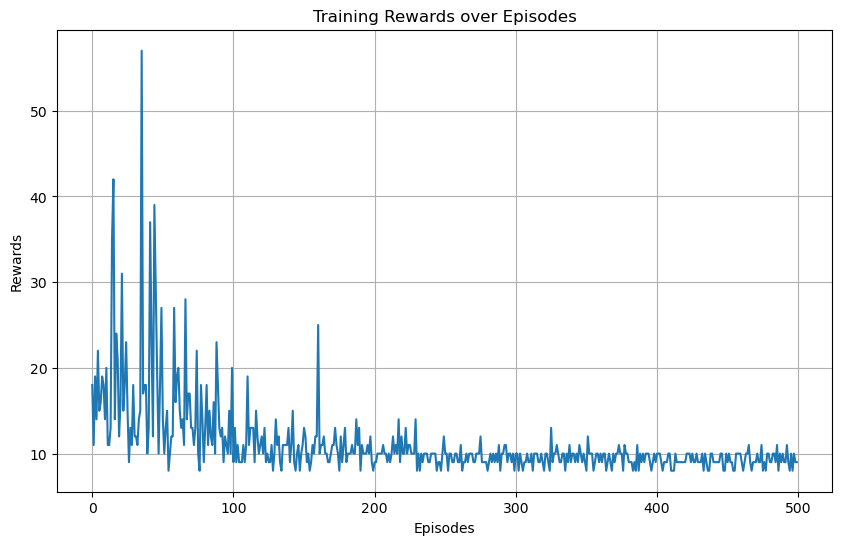

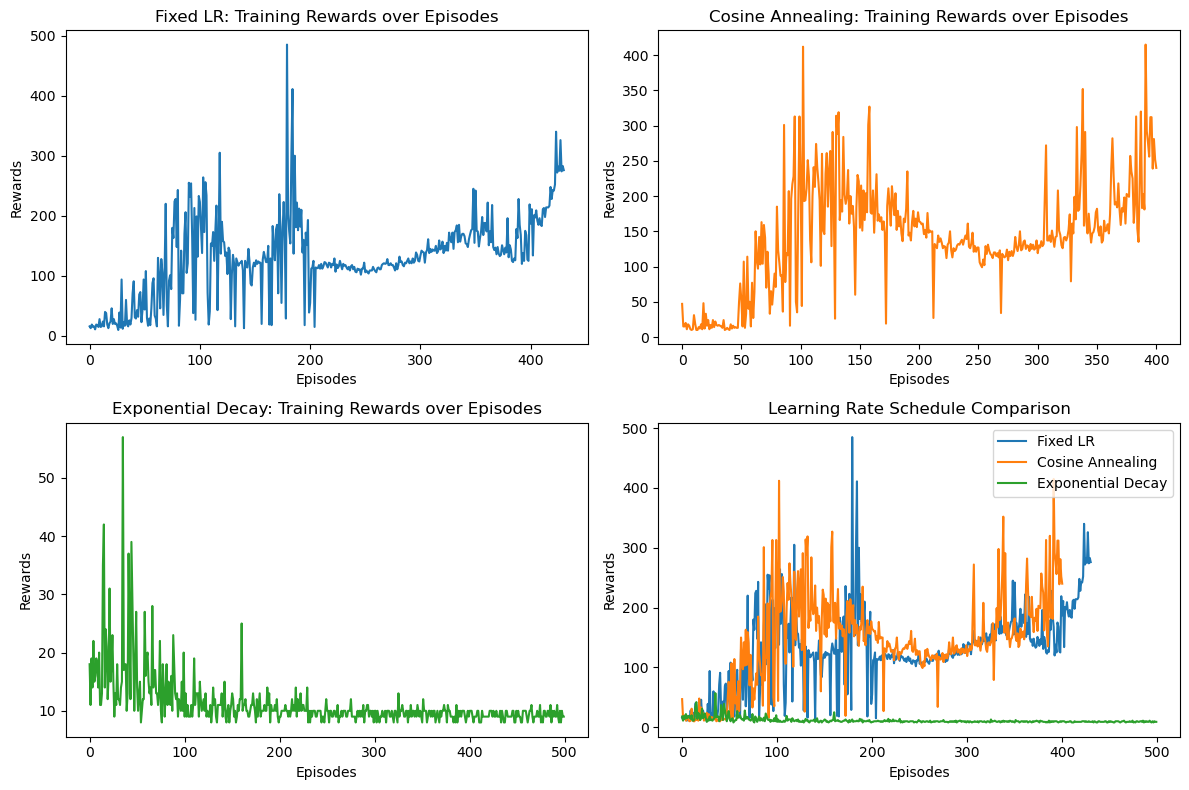

In [14]:
# Run experiments with different learning rate schedules
fixed_rewards = run_experiment(DQLAgentFineTuned, env, {'lr_schedule': 'fixed'})
cosine_rewards = run_experiment(DQLAgentFineTuned, env, {'lr_schedule': 'cosine'})
exp_rewards = run_experiment(DQLAgentFineTuned, env, {'lr_schedule': 'exponential'})

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot Training Rewards over Episodes in each subplot
axes[0, 0].plot(fixed_rewards, color='#1f77b4') 
axes[0, 0].set_title("Fixed LR: Training Rewards over Episodes")
axes[0, 0].set_xlabel("Episodes")
axes[0, 0].set_ylabel("Rewards")

axes[0, 1].plot(cosine_rewards, color='#ff7f0e') 
axes[0, 1].set_title("Cosine Annealing: Training Rewards over Episodes")
axes[0, 1].set_xlabel("Episodes")
axes[0, 1].set_ylabel("Rewards")

axes[1, 0].plot(exp_rewards, color='#2ca02c')  
axes[1, 0].set_title("Exponential Decay: Training Rewards over Episodes")
axes[1, 0].set_xlabel("Episodes")
axes[1, 0].set_ylabel("Rewards")

# Plot learning rate schedule comparison
axes[1, 1].plot(fixed_rewards, label='Fixed LR')
axes[1, 1].plot(cosine_rewards, label='Cosine Annealing')
axes[1, 1].plot(exp_rewards, label='Exponential Decay')
axes[1, 1].set_title("Learning Rate Schedule Comparison")
axes[1, 1].set_xlabel("Episodes")
axes[1, 1].set_ylabel("Rewards")
axes[1, 1].legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


### Deeper Neural Network

The original network had 2 hidden layers (128, 128 neurons). 

In this section we compare:
- Baseline (128, 128)
- Larger hidden layers (256, 256)
- Deeper network (128, 128, 128)

In [15]:
class DQNDeep(nn.Module):
    def __init__(self, state_size, action_size, hidden_layers=[256, 256]):
        super(DQNDeep, self).__init__()
        layers = []
        input_size = state_size
        
        for hidden in hidden_layers:
            layers.append(nn.Linear(input_size, hidden))
            layers.append(nn.ReLU())
            input_size = hidden
        
        layers.append(nn.Linear(input_size, action_size))
        self.model = nn.Sequential(*layers)
        
        # Initialize weights
        for layer in self.model:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
    
    def forward(self, state):
        return self.model(state)

# Custom Agent Class for Deep Networks
class DQLAgentDeep(DQLAgent):
    def __init__(self, env, hidden_layers=[256, 256], **kwargs):
        super().__init__(env, **kwargs)
        
        # Replace the default Q-network with the deeper network
        self.q_network = DQNDeep(self.state_size, self.action_size, hidden_layers)
        self.target_network = DQNDeep(self.state_size, self.action_size, hidden_layers)
        
        # Copy weights from Q-network to target network
        self.target_network.load_state_dict(self.q_network.state_dict())

        # Reinitialize optimizer for the new network
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=self.lr)

### Run and compare performance

Episode 0/500, Total Reward: 20.0, Avg(last 1): 20.00, Epsilon: 0.990
Episode 10/500, Total Reward: 15.0, Avg(last 10): 18.80, Epsilon: 0.895
Episode 20/500, Total Reward: 16.0, Avg(last 10): 26.40, Epsilon: 0.810
Episode 30/500, Total Reward: 51.0, Avg(last 10): 29.30, Epsilon: 0.732
Episode 40/500, Total Reward: 98.0, Avg(last 10): 60.00, Epsilon: 0.662
Episode 50/500, Total Reward: 34.0, Avg(last 10): 58.80, Epsilon: 0.599
Episode 60/500, Total Reward: 60.0, Avg(last 10): 104.50, Epsilon: 0.542
Episode 70/500, Total Reward: 62.0, Avg(last 10): 97.30, Epsilon: 0.490
Episode 80/500, Total Reward: 33.0, Avg(last 10): 106.60, Epsilon: 0.443
Episode 90/500, Total Reward: 54.0, Avg(last 10): 93.50, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 145.0, Avg(last 10): 126.20, Epsilon: 0.362
Episode 110/500, Total Reward: 140.0, Avg(last 10): 111.30, Epsilon: 0.328
Episode 120/500, Total Reward: 119.0, Avg(last 10): 113.00, Epsilon: 0.296
Episode 130/500, Tota

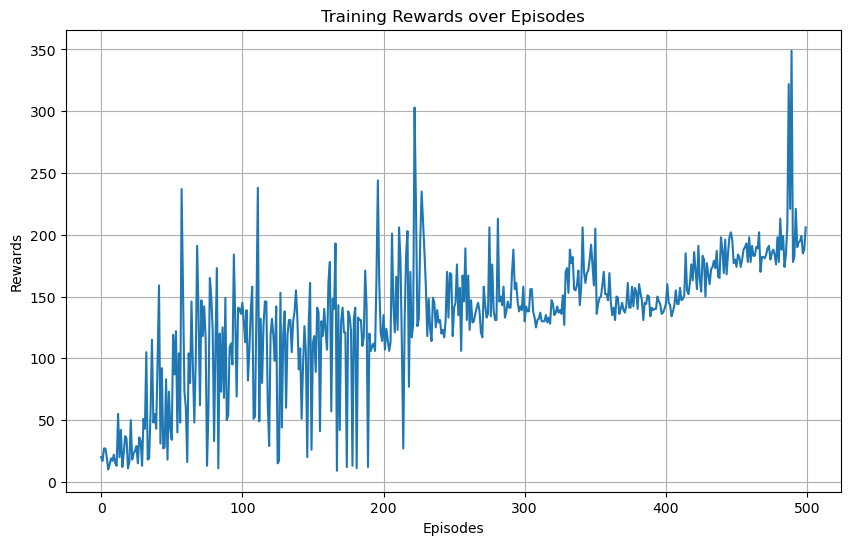

Episode 0/500, Total Reward: 21.0, Avg(last 1): 21.00, Epsilon: 0.990
Episode 10/500, Total Reward: 14.0, Avg(last 10): 23.10, Epsilon: 0.895
Episode 20/500, Total Reward: 10.0, Avg(last 10): 17.90, Epsilon: 0.810
Episode 30/500, Total Reward: 19.0, Avg(last 10): 19.90, Epsilon: 0.732
Episode 40/500, Total Reward: 20.0, Avg(last 10): 35.10, Epsilon: 0.662
Episode 50/500, Total Reward: 26.0, Avg(last 10): 45.60, Epsilon: 0.599
Episode 60/500, Total Reward: 158.0, Avg(last 10): 100.70, Epsilon: 0.542
Episode 70/500, Total Reward: 159.0, Avg(last 10): 99.30, Epsilon: 0.490
Episode 80/500, Total Reward: 128.0, Avg(last 10): 168.80, Epsilon: 0.443
Episode 90/500, Total Reward: 189.0, Avg(last 10): 111.80, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 47.0, Avg(last 10): 131.00, Epsilon: 0.362
Episode 110/500, Total Reward: 157.0, Avg(last 10): 121.20, Epsilon: 0.328
Episode 120/500, Total Reward: 143.0, Avg(last 10): 103.80, Epsilon: 0.296
Episode 130/500, 

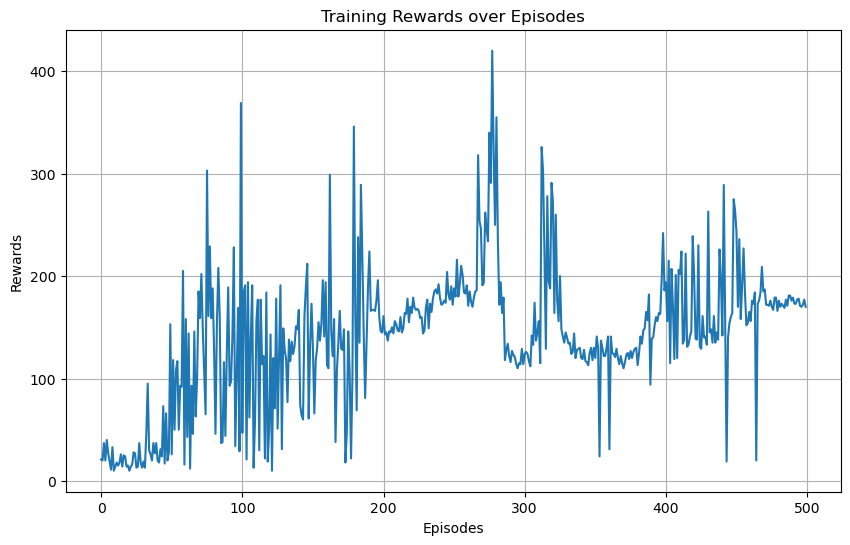

Episode 0/500, Total Reward: 22.0, Avg(last 1): 22.00, Epsilon: 0.990
Episode 10/500, Total Reward: 16.0, Avg(last 10): 16.90, Epsilon: 0.895
Episode 20/500, Total Reward: 29.0, Avg(last 10): 27.70, Epsilon: 0.810
Episode 30/500, Total Reward: 51.0, Avg(last 10): 31.20, Epsilon: 0.732
Episode 40/500, Total Reward: 34.0, Avg(last 10): 41.70, Epsilon: 0.662
Episode 50/500, Total Reward: 107.0, Avg(last 10): 49.30, Epsilon: 0.599
Episode 60/500, Total Reward: 86.0, Avg(last 10): 66.00, Epsilon: 0.542
Episode 70/500, Total Reward: 67.0, Avg(last 10): 73.10, Epsilon: 0.490
Episode 80/500, Total Reward: 15.0, Avg(last 10): 69.30, Epsilon: 0.443
Episode 90/500, Total Reward: 68.0, Avg(last 10): 106.20, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 66.0, Avg(last 10): 109.50, Epsilon: 0.362
Episode 110/500, Total Reward: 43.0, Avg(last 10): 90.20, Epsilon: 0.328
Episode 120/500, Total Reward: 264.0, Avg(last 10): 181.30, Epsilon: 0.296
Episode 130/500, Total R

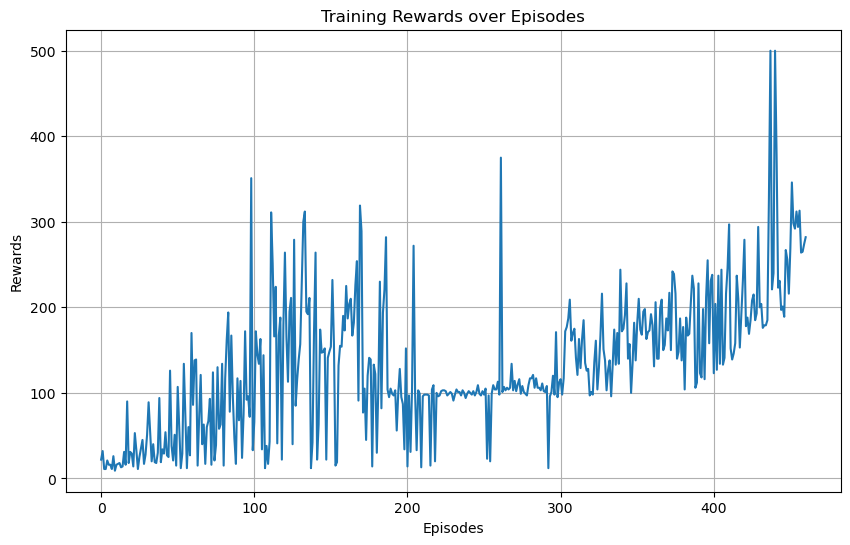

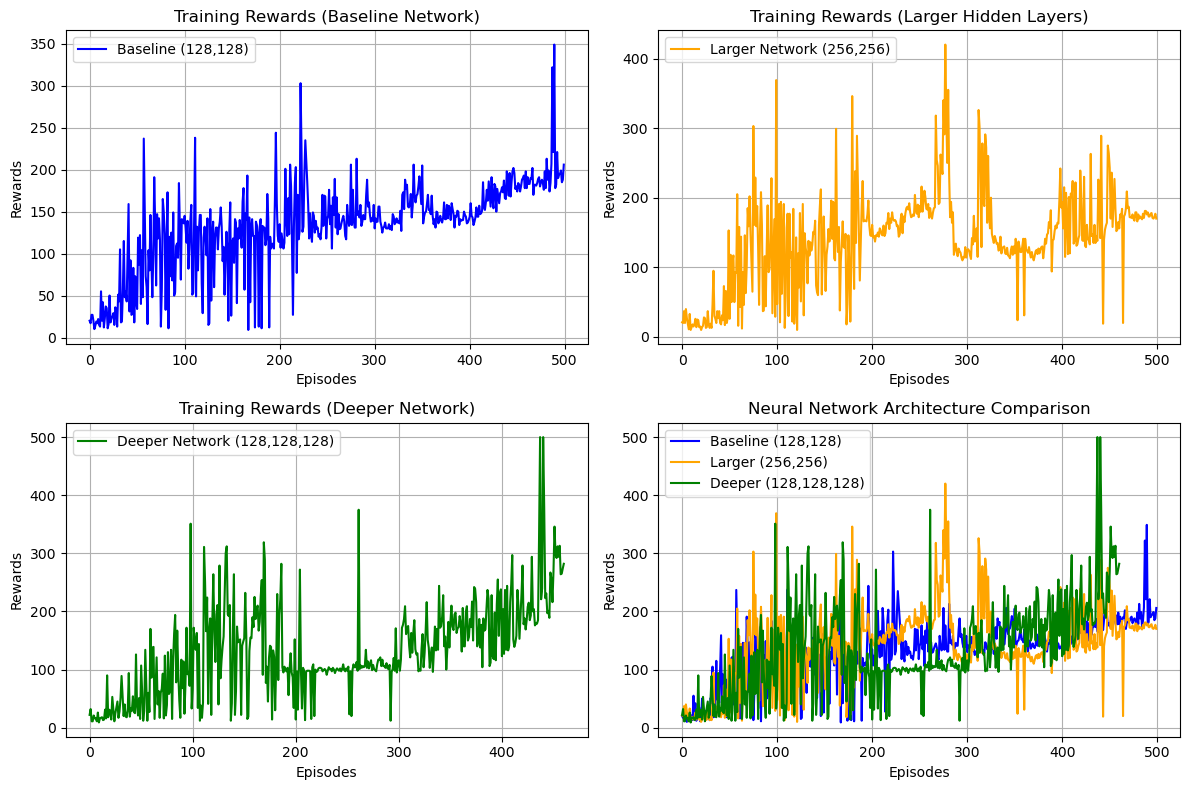

In [16]:
# Run experiments for different network architectures
baseline_rewards = run_experiment(DQLAgent, env, {})  # Baseline (128,128)
deep_rewards = run_experiment(DQLAgentDeep, env, {'hidden_layers': [256, 256]})  # Larger Hidden Layers
deep3_rewards = run_experiment(DQLAgentDeep, env, {'hidden_layers': [128, 128, 128]})  # Deeper Network

# Plot results
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(baseline_rewards, label='Baseline (128,128)', color='blue')
axs[0, 0].set_title("Training Rewards (Baseline Network)")
axs[0, 0].set_xlabel("Episodes")
axs[0, 0].set_ylabel("Rewards")
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].plot(deep_rewards, label='Larger Network (256,256)', color='orange')
axs[0, 1].set_title("Training Rewards (Larger Hidden Layers)")
axs[0, 1].set_xlabel("Episodes")
axs[0, 1].set_ylabel("Rewards")
axs[0, 1].legend()
axs[0, 1].grid(True)

axs[1, 0].plot(deep3_rewards, label='Deeper Network (128,128,128)', color='green')
axs[1, 0].set_title("Training Rewards (Deeper Network)")
axs[1, 0].set_xlabel("Episodes")
axs[1, 0].set_ylabel("Rewards")
axs[1, 0].legend()
axs[1, 0].grid(True)

# Combined comparison plot
axs[1, 1].plot(baseline_rewards, label='Baseline (128,128)', color='blue')
axs[1, 1].plot(deep_rewards, label='Larger (256,256)', color='orange')
axs[1, 1].plot(deep3_rewards, label='Deeper (128,128,128)', color='green')
axs[1, 1].set_title("Neural Network Architecture Comparison")
axs[1, 1].set_xlabel("Episodes")
axs[1, 1].set_ylabel("Rewards")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# IGNORE THE CELLS BELOW FOR NOW

### Alternative Optimizers

Instead of using Adam, we test:

- AdamW: A variation of Adam with weight decay (better generalization).
- RMSprop: A momentum-based optimizer, good for noisy environments.

class DQLAgentOptimized(DQLAgent):
    def __init__(self, env, optimizer_type='adamw', **kwargs):
        super().__init__(env, **kwargs)
        
        if optimizer_type == 'adamw':
            self.optimizer = optim.AdamW(self.q_network.parameters(), lr=self.lr)
        elif optimizer_type == 'rmsprop':
            self.optimizer = optim.RMSprop(self.q_network.parameters(), lr=self.lr)


### Reward Shaping 

Instead of using only +1 per step, we modify rewards:

- Penalize large pole angles (preventing it from tilting too much).
- Penalize cart velocity (encouraging stability).

class DQLAgentRewardShaping(DQLAgent):
    def reward_shaping(self, state, reward):
        pole_angle = state[2]
        cart_velocity = abs(state[1])
        shaped_reward = reward - (0.1 * abs(pole_angle)) - (0.05 * cart_velocity)
        return shaped_reward
    
    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        rewards = [self.reward_shaping(s, r) for s, r in zip(states, rewards)]
        
        super().train_step()


### Exploration Strategies

Instead of epsilon-greedy, we test:

- Softmax Exploration: Chooses actions probabilistically based on Q-values.
- Upper Confidence Bound (UCB): Uses a balance of exploration and exploitation.

class DQLAgentExploration(DQLAgent):
    def __init__(self, env, exploration_strategy='softmax', **kwargs):
        super().__init__(env, **kwargs)
        self.exploration_strategy = exploration_strategy
    
    def select_action(self, state, training=True):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        
        if training:
            if self.exploration_strategy == 'softmax':
                probs = F.softmax(q_values / (self.epsilon + 1e-8), dim=1).numpy()
                return np.random.choice(self.action_size, p=probs[0])
            elif self.exploration_strategy == 'ucb':
                return np.argmax(q_values.numpy() + np.sqrt(2 * np.log(sum(self.memory)) / (1 + np.array(self.memory))))
        
        return torch.argmax(q_values).item()
